# Lab 2 - Challenge continuation + splines

Lucas Schwengber/Josh Davis

This week we will continue the linear regression challenge. Check in Lab
1 [instructions](../lab1_linreg_intro/exercise.qmd) for what you should
aim at accomplishing by the end of the lab.

This presentation’s goal is introducing a technique you may use to
handle the non-linear features, which is important to know for more
realistic scenarios.

This challenge is unusually unrealistic in that one may correctly guess
a closed form expression for the non-linear features, as some of you
did.

Although you could in principle get zero error without using splines, we
recommend experimenting with splines since they provide a more realistic
handle to work on real problems.

## Intractable targets

Imagine you are given data from the function below, which has no
closed-form expression.

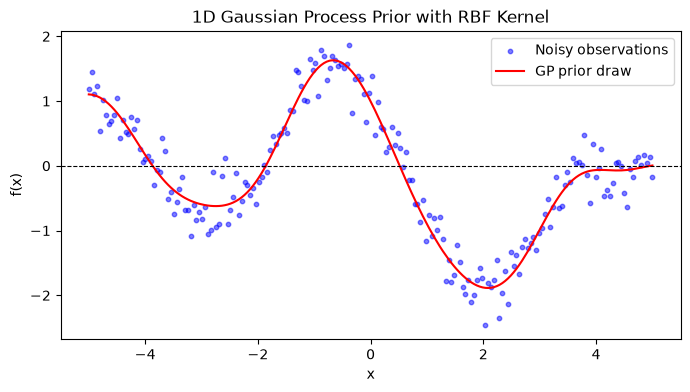

In [6]:
import numpy as np

import matplotlib.pyplot as plt

# Input locations
x = np.linspace(-5, 5, 200)

# RBF kernel
length_scale = 1.0
variance = 1.0
X1, X2 = np.meshgrid(x, x)
K = variance * np.exp(-0.5 * ((X1 - X2) / length_scale) ** 2)

# Draw one sample from the GP prior
rng = np.random.default_rng(42)
f_sample = rng.multivariate_normal(
    mean=np.zeros(len(x)),
    cov=K + 1e-8 * np.eye(len(x))
)
y = f_sample + 0.25 * rng.normal(size=len(x))  # Add some noise

# Plot the draw
plt.figure(figsize=(8, 4))
plt.scatter(x, y, label="Noisy observations", s=10, color="blue", alpha=0.5)
plt.plot(x, f_sample, label="GP prior draw", c="red")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("1D Gaussian Process Prior with RBF Kernel")
plt.legend()
plt.show()

Assuming you do not know what a Gaussian process is, how could you try
to use linear regression to approximate this function?

One natural follow-up from the idea of adding non-linear features, is
just trying to add a bunch of them and hoping that some linear
combination of them approximates well the ground-truth function.
Possibilities are, say, adding in polynomials of all degrees up to some
high-degree, or using trigonometric polynomials with increasing
frequencies.

Given unlimited resources, both strategies could in principle work, but
they have some short comings for realistic problems. Can you think of
some of them?

There is a wide zoo of recommended choices of flexible basis for
expressing large functions classes as linear models. We will focus on
one particular choice called splines, which balances well issues that
might arise from using such expressive basis of features.

## Splines

As you probably saw in class, one possible way of trying to approximate
an arbitrary regression function using linear regression, is by defining
the following set of features:

$$\phi_k(x) = I(x \in (t_k,t_{k+1}]),$$

where $t_k < t_{k+1}$ is a fine partition of the domain where $x$ lives.
If we fit linear regression with this basis, we will obtain a piecewise
constant function as seen below.

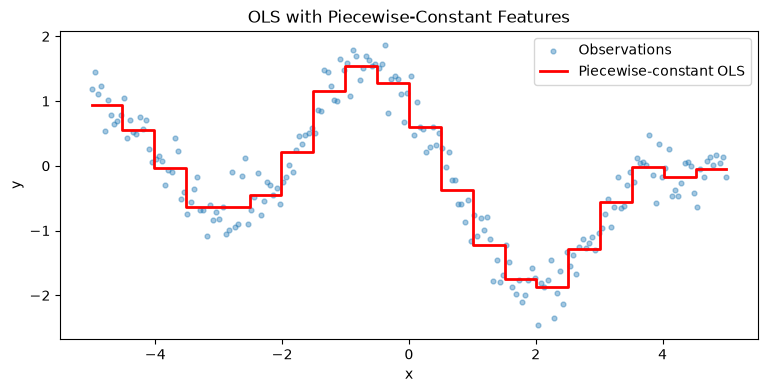

In [19]:
step = 0.5
edges = np.arange(x.min(), x.max() + step, step)
bin_index = np.digitize(x, edges[1:-1])

# One-hot piecewise-constant feature basis
x_piecewise_ct = np.eye(len(edges) - 1)[bin_index]

# OLS fit
beta_hat, *_ = np.linalg.lstsq(x_piecewise_ct, y, rcond=None)
y_hat = x_piecewise_ct @ beta_hat

plt.figure(figsize=(9, 4))
plt.scatter(x, y, s=12, alpha=0.4, label="Observations")
plt.step(x, y_hat, where="mid", color="red", linewidth=2,
         label="Piecewise-constant OLS")
plt.xlabel("x")
plt.ylabel("y")
plt.title("OLS with Piecewise-Constant Features")
plt.legend()
plt.show()

This provides a reasonably flexible approximation of our regression
function. We can further generalize this idea, and instead of fitting a
constant per interval, we can fit one polynomial per interval, say of
some arbitrary degree.

One drawback from such approaches is that the number of parameters
increases rather fast, and we are refraining from using certain
assumptions from the regression function that seem reasonable here: that
it’s probably smooth. Splines are essentially a way of fixing this.

We fit local polynomials with the additional restriction that at the
joints between the intervals the fitted polynomials in the intervals
have the same derivative up to highest degree minus one, where we
consider the zeroth derivative as the value of the function itself. So
for example, a piecewise linear function continuous at the joints of the
intervals count as a degree 1 spline (as we will see below).

There are more than one way of achieving this, we will use B-splines,
which are recursively defined via (see
[this](https://www.alexkaizer.com/bios_6618/files/bios6618/W16/splines.pdf)):

$$B_k^d(x) = \frac{x - t_k}{t_{k+d} - t_k} B_k^{d-1}(x) + \frac{t_{k+d+1} - x}{t_{k+d+1} - t_{k+1}} B_{k+1}^{d-1}(x)$$

for $k = 1, \dots, d + K + 1$ where

$$B_k^0(x) =
\begin{cases}
1 & t_k \le x < t_{k+1} \\
0 & \text{else}
\end{cases}$$

and $B_k^0(x) \equiv 0$ if $t_k = t_{k+1}$.

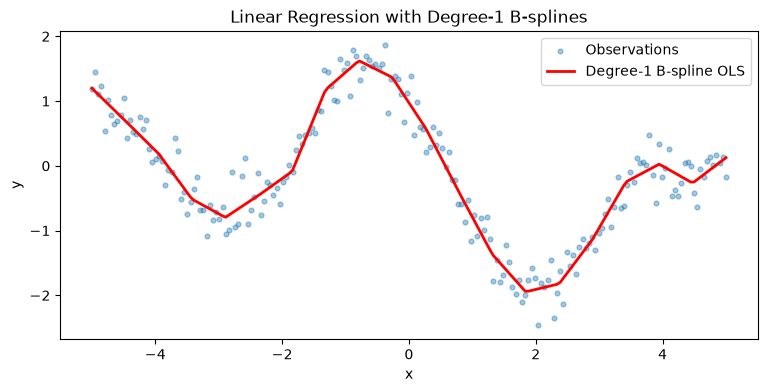

In [21]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

# Construct degree-1 B-spline features
spline_deg1_transf = SplineTransformer(
    n_knots=20,
    degree=1,
    knots="uniform",
    include_bias=False
)

x_spline_deg1 = spline_deg1_transf.fit_transform(x[:, None])

# Fit linear regression using the spline basis
spline_model = LinearRegression()
spline_model.fit(x_spline_deg1, y)

y_spline_deg1_hat = spline_model.predict(x_spline_deg1)

# Plot the fitted spline regression
plt.figure(figsize=(9, 4))
plt.scatter(x, y, s=12, alpha=0.4, label="Observations")
plt.plot(x, y_spline_deg1_hat, color="red", linewidth=2, label="Degree-1 B-spline OLS")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Degree-1 B-splines")
plt.legend()
plt.show()

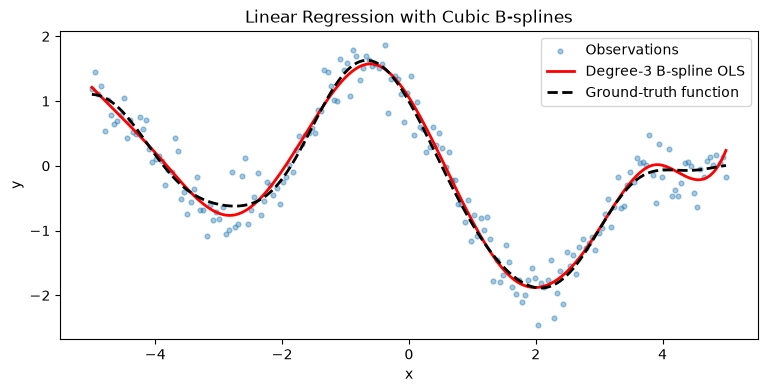

In [26]:
# Construct degree-3 (cubic) B-spline features
spline_deg3_transf = SplineTransformer(
    n_knots=10,
    degree=3,
    knots="uniform",
    include_bias=False
)

x_spline_deg3 = spline_deg3_transf.fit_transform(x[:, None])

# Fit linear regression using the cubic spline basis
spline_deg3_model = LinearRegression()
spline_deg3_model.fit(x_spline_deg3, y)

y_spline_deg3_hat = spline_deg3_model.predict(x_spline_deg3)

# Plot the fitted cubic spline regression
plt.figure(figsize=(9, 4))
plt.scatter(x, y, s=12, alpha=0.4, label="Observations")
plt.plot(
    x,
    y_spline_deg3_hat,
    color="red",
    linewidth=2,
    label="Degree-3 B-spline OLS"
)
plt.plot(
    x,
    f_sample,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Ground-truth function"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Cubic B-splines")
plt.legend()
plt.show()

In [25]:
print("Number of observations:", x_spline_deg3.shape[0])
print("Number of B-spline features:", x_spline_deg3.shape[1])

Number of observations: 200
Number of B-spline features: 11

In [29]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42
)
def fit_ols_predict(X):
    model = LinearRegression()
    model.fit(X[train_idx], y[train_idx])
    return model.predict(X[test_idx])

y_piecewise_test = fit_ols_predict(x_piecewise_ct)
y_spline_linear_test = fit_ols_predict(x_spline_deg1)
y_spline_cubic_test = fit_ols_predict(x_spline_deg3)

y_mean_test = np.full(len(test_idx), np.mean(y[train_idx]))

mse_ground_truth_test = np.mean(
    (y[test_idx] - f_sample[test_idx]) ** 2
)
mse_piecewise_test = np.mean(
    (y[test_idx] - y_piecewise_test) ** 2
)
mse_spline_linear_test = np.mean(
    (y[test_idx] - y_spline_linear_test) ** 2
)
mse_spline_cubic_test = np.mean(
    (y[test_idx] - y_spline_cubic_test) ** 2
)
mse_mean_test = np.mean(
    (y[test_idx] - y_mean_test) ** 2
)

print(f"Ground-truth function MSE: {mse_ground_truth_test:.4f}")
print(f"Piecewise-constant MSE:    {mse_piecewise_test:.4f}")
print(f"Degree-1 spline MSE:       {mse_spline_linear_test:.4f}")
print(f"Cubic spline MSE:          {mse_spline_cubic_test:.4f}")
print(f"Mean prediction MSE:       {mse_mean_test:.4f}")

Ground-truth function MSE: 0.0602
Piecewise-constant MSE:    0.1126
Degree-1 spline MSE:       0.0739
Cubic spline MSE:          0.0691
Mean prediction MSE:       1.1366

Although there are some small mismatches relative to the ground-truth
function, one can see that they are small, and we ended up being able to
recover the overall shape from the data without having to guess. The MSE
obtained from the last two spline basis is very close from the one
obtained using the ground-truth function. For most practical
circumstances this difference is negligible.

If one is primarily interested in doing prediction and getting a low
MSE, the splines on this case are as good as the ground-truth function.
A similar reasoning holds for the lab. Although in principle one could
get zero error, for prediction purposes, one can get a near zero score
using splines, with a lower effort.

It’s good to keep in mind that for situations in which inference is
relevant, or if you want to reverse engineer the exact function in case
that is possible, techniques other than splines may be more suitable.